In [1]:
import os
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import cv2
import math
from skimage.morphology import skeletonize, medial_axis
from scipy import ndimage

In [2]:
base_dir = Path("images")

images = {}

for subdir in base_dir.iterdir():
    if subdir.is_dir():
        img_dict = {}
        for img_file in subdir.glob("*.[pj][pn]g"):  # matches .png and .jpg
            img_dict[img_file.name] = Image.open(img_file)
        images[subdir.name] = img_dict

print(f"Loaded {sum(len(v) for v in images.values())} images across {len(images)} categories.")

Loaded 10 images across 3 categories.


In [3]:
def print_image_shapes(images_dict):
    """
    Print the shape and dtype of every image in the nested dictionary.
    """
    for level, img_set in images_dict.items():
        print(f"\n=== Level: {level} ===")
        for img_name, img in img_set.items():
            
            # Convert PIL → NumPy for shape/dtype
            if isinstance(img, Image.Image):
                arr = np.array(img)
            else:
                arr = img

            print(f"{img_name:<20}  shape={arr.shape}  dtype={arr.dtype}")


print_image_shapes(images)


=== Level: easy ===
easy.jpg              shape=(459, 612, 3)  dtype=uint8
29.png                shape=(318, 477, 3)  dtype=uint8
20.png                shape=(630, 1200, 3)  dtype=uint8
not_that_easy.jpg     shape=(433, 612, 3)  dtype=uint8

=== Level: medium ===
12.png                shape=(1080, 1920, 3)  dtype=uint8
31.png                shape=(827, 1412, 3)  dtype=uint8
30.png                shape=(204, 890, 3)  dtype=uint8

=== Level: hard ===
frame600.jpg          shape=(2160, 3840, 3)  dtype=uint8
21.png                shape=(733, 1100, 3)  dtype=uint8
frame1.jpg            shape=(2160, 3840, 3)  dtype=uint8


In [4]:
def do_tophat(grey_image, tophat_kernel, name="Tophat Test", debug=True):
    # horiz_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    # horiz_lines = cv2.morphologyEx(img_grey, cv2.MORPH_OPEN, horiz_kernel)
    hat_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, tophat_kernel)
    tophat = cv2.morphologyEx(grey_image, cv2.MORPH_TOPHAT, hat_kernel)
    
    if debug:
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(tophat, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")

    return tophat
    
def binarise(image, name="Binarise Test", debug=True):
    _, binary = cv2.threshold(image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    if debug:
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(binary, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")

    return binary
    

def clean_binary(binary, horizon, name="Binary Cleaned", debug=True):
    # open + close
    
    if horizon:
        opening_size = (7, 1)
        closing_size = (30, 1)
    else:
        opening_size = (1, 7)
        closing_size = (1, 30)
        
    # remove small blobs/noise
    k1 = cv2.getStructuringElement(cv2.MORPH_RECT, opening_size)
    out = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k1)

    # connect broken horizontal line segments
    k2 = cv2.getStructuringElement(cv2.MORPH_RECT, closing_size)
    out = cv2.morphologyEx(out, cv2.MORPH_CLOSE, k2)

    if debug:
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")
    
    return out

def clean_tophat(image, horizon, name="Tophat Cleaned", debug=True):
    
    if horizon:
        element_size = (3, 31)
    else:
        element_size = (31, 3)

    out = cv2.GaussianBlur(image, element_size, 0)

    if debug:
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")
    
    return out

In [5]:
def do_skeletonisation(image, name="Skeleton Test", debug=True):
    # Convert to boolean (skeletonize requires boolean mask)
    bool_img = (image > 0)

    skel = skeletonize(bool_img)

    # Convert back to uint8
    skel_u8 = (skel * 255).astype(np.uint8)

    if debug:
        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(skel_u8, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")
    
    return skel_u8

In [6]:
def directional_open(image, horizon=True, ksize=40, name="Directional Open", debug=True):
    
    if horizon:
        # horizontal line extraction, wide kernel
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (ksize, 1))
    else:
        # vertical line extraction, tall kernel
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, ksize))

    # Apply morphological opening
    lines = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(lines, cmap="gray")
        plt.title(name)
        plt.axis("off")

    return lines


In [7]:
def fast_dominant_line_angle(img, name="Fast Line Angle", debug=True):

    # 2. Light blur
    blur = cv2.GaussianBlur(img, (5,5), 0)

    # 3. Fast edges
    edges = cv2.Canny(blur, 50, 150)

    # 4. Connect long edges
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15,1))
    edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    # 5. Aggressive Hough
    lines = cv2.HoughLinesP(
        edges, 1, np.pi/180,
        threshold=200,
        minLineLength=150,
        maxLineGap=20
    )

    if lines is None:
        if debug:
            print("No lines detected.")
        return None
    
    # pick the longest line
    longest = max(lines, key=lambda L: np.hypot(L[0][2]-L[0][0], L[0][3]-L[0][1]))
    x1, y1, x2, y2 = longest[0]
    angle = np.degrees(np.arctan2(y2-y1, x2-x1))

    if debug:
        length = np.hypot(x2 - x1, y2 - y1)
        print(f"Dominant line: ({x1},{y1}) → ({x2},{y2}), length={length:.2f}, angle={angle:.2f}")
        vis = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2BGR)
        cv2.line(vis, (x1, y1), (x2, y2), (0,255,255), 5)

        plt.figure(figsize=(8,8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title(name)
        plt.axis("off")
    
   
    return angle


In [8]:
def rotate_image_with_reflect(img, angle):
    """
    Rotate an image by 'angle' degrees, keeping the original size.
    The new borders are filled using reflection padding.
    Returns:
        rotated     - rotated image (same size as input)
        M           - forward affine transform
        Minv        - inverse affine transform
        valid_mask  - mask showing which pixels came from the original image
    """

    h, w = img.shape[:2]
    center = (w/2, h/2)

    # --- 1. Rotation matrix (keeps output same size) ---
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # --- 2. Create mask of original image area ---
    mask = np.ones((h, w), dtype=np.uint8)*255

    # --- 3. Pad the image with reflection BEFORE rotating ---
    # To avoid black corners
    pad = max(h, w)   # safe padding amount
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad,
                                cv2.BORDER_REFLECT_101)
    padded_mask = cv2.copyMakeBorder(mask, pad, pad, pad, pad,
                                     cv2.BORDER_REFLECT_101)

    # Update center because image is padded
    ph, pw = padded.shape[:2]
    new_center = (pw/2, ph/2)
    M_pad = cv2.getRotationMatrix2D(new_center, angle, 1.0)

    # --- 4. Rotate padded image ---
    rotated_large = cv2.warpAffine(
        padded, M_pad, (pw, ph), flags=cv2.INTER_LINEAR
    )

    # Rotate padded mask also
    rotated_mask = cv2.warpAffine(
        padded_mask, M_pad, (pw, ph), flags=cv2.INTER_NEAREST
    )

    # --- 5. Extract center region of original size ---
    x1 = (pw - w) // 2
    y1 = (ph - h) // 2
    rotated = rotated_large[y1:y1+h, x1:x1+w]
    valid_mask = rotated_mask[y1:y1+h, x1:x1+w]

    # --- 6. Inverse transform for mapping back ---
    Minv = cv2.invertAffineTransform(M)

    return rotated, M, Minv, valid_mask


In [9]:
def get_canny_edges_auto(grey, sigma=0.33, debug=True, title="Canny Edges (Auto)"):

    # Estimate noise level using median
    v = np.median(grey)

    # Automatic thresholds
    low  = int(max(0, (1.0 - sigma) * v))
    high = int(min(255, (1.0 + sigma) * v))

    edges = cv2.Canny(grey, low, high)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(edges, cmap="gray")
        plt.title(f"{title} (low={low}, high={high})")
        plt.axis("off")

    return edges


In [10]:
def and_binary(img1, img2, debug=True, title="Binary AND"):
    """
    Perform pixel-wise AND on two binary images (values must be 0 or 255).
    Images must be the same size.
    """

    # ensure same size
    if img1.shape != img2.shape:
        raise ValueError("and_binary: images must have the same shape")

    # perform logical AND
    out = cv2.bitwise_and(img1, img2)

    if debug:
        plt.figure(figsize=(8, 8))
        plt.imshow(out, cmap="gray")
        plt.title(title)
        plt.axis("off")

    return out

In [38]:
def lsd_detect_and_show(gray_image, show=True):
    """
    Run LSD (Line Segment Detector) on a grayscale image.

    Parameters
    ----------
    gray_image : np.ndarray
        2D NumPy array (H x W), dtype uint8 preferred.
    show : bool
        If True, displays the image with detected lines overlaid.

    Returns
    -------
    lines : np.ndarray or None
        Detected line segments as an array of shape (N, 4):
        [x1, y1, x2, y2] per row, or None if no lines are found.
    """
    # Ensure the image is single-channel 8-bit
    if len(gray_image.shape) != 2:
        raise ValueError("Input must be a single-channel (grayscale) image.")
    if gray_image.dtype != np.uint8:
        gray_image = cv2.normalize(gray_image, None, 0, 255, cv2.NORM_MINMAX)
        gray_image = gray_image.astype(np.uint8)

    # Create the LSD detector
    lsd = cv2.createLineSegmentDetector(refine=cv2.LSD_REFINE_STD)

    # Detect line segments
    lines = lsd.detect(gray_image)[0]  # lines is None if nothing detected

    if lines is not None:
        # lines has shape (N, 1, 4); reshape to (N, 4)
        lines = lines.reshape(-1, 4)

        # Prepare a BGR version of the grayscale image for drawing
        color_img = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

        # Draw the detected line segments on the color image
        drawn_img = lsd.drawSegments(color_img, lines)
    else:
        drawn_img = cv2.cvtColor(gray_image, cv2.COLOR_GRAY2BGR)

    # Display result if requested
    if show:
        plt.figure(figsize=(8, 8))
        # Convert BGR (OpenCV) to RGB (matplotlib)
        plt.imshow(cv2.cvtColor(drawn_img, cv2.COLOR_BGR2RGB))
        plt.title("LSD Detected Line Segments")
        plt.axis("off")
        plt.show()

    return lines

In [47]:
# Function to do the pipeline on the whole image.
def do_pipeline(images_array, set_name, image_name):

    # grab the image from the array.
    img = images_array[set_name][image_name]
    print(f"{image_name} from the {set_name} set")
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(f"{image_name} from {set_name}")
    plt.axis("off")
    
    img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    img_grey = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # angle = fast_dominant_line_angle(img_grey, name="Greyscale Skeleton Test")
    # rotated, M, Minv, valid_mask = rotate_image_with_reflect(img_grey, angle)
    #
    # plt.figure(figsize=(8,8))
    # plt.imshow(cv2.cvtColor(rotated, cv2.COLOR_BGR2RGB))
    # plt.title("Rotated")
    # plt.axis("off")
    blurred = cv2.GaussianBlur(img_grey, (5,5), 0)
    # --- Directional Morphology (Opening) ---
    horiz_lines = directional_open(
        blurred, horizon=True, ksize=40, name="Horizontal Opening"
    )

    vert_lines = directional_open(
        blurred, horizon=False, ksize=40, name="Vertical Opening"
    )
    # --- Top-Hat Enhancement ---
    vertical_tophat = do_tophat(
        vert_lines, (40, 3), name="Vertical Tophat Test"
    )
    horizon_tophat = do_tophat(
        horiz_lines, (3, 40), name="Horizontal Tophat Test"
    )

    # --- Clean Top-Hat Output ---
    horizon_clean = clean_tophat(
        horizon_tophat, False, name="Tophat Horizon Cleaned"
    )
    vertical_clean = clean_tophat(
        vertical_tophat, True, name="Tophat Vertical Cleaned"
    )
    lines = lsd_detect_and_show(horizon_clean, show=True)
    lines = lsd_detect_and_show(vertical_clean, show=True)

    #and_binary(canny_vertical, vertical_clean)

    return

21.png from the hard set


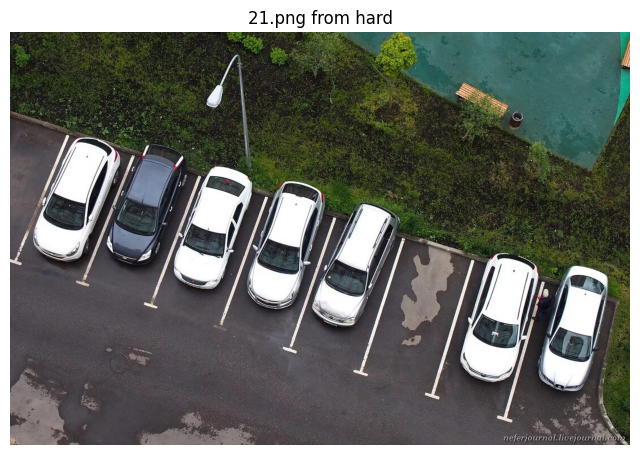

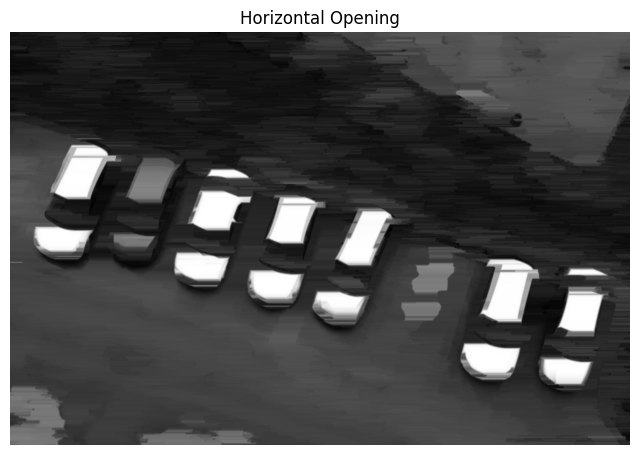

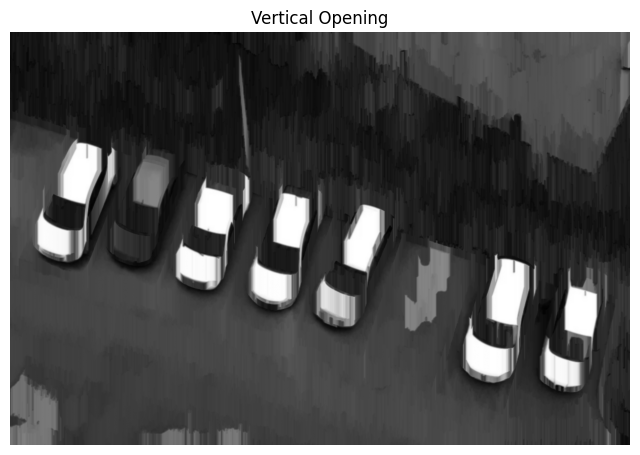

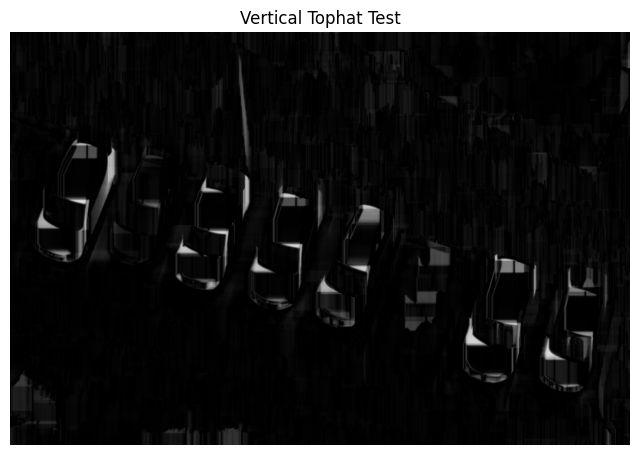

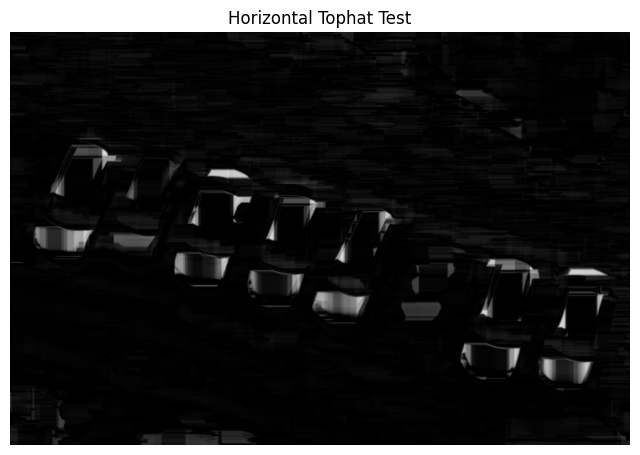

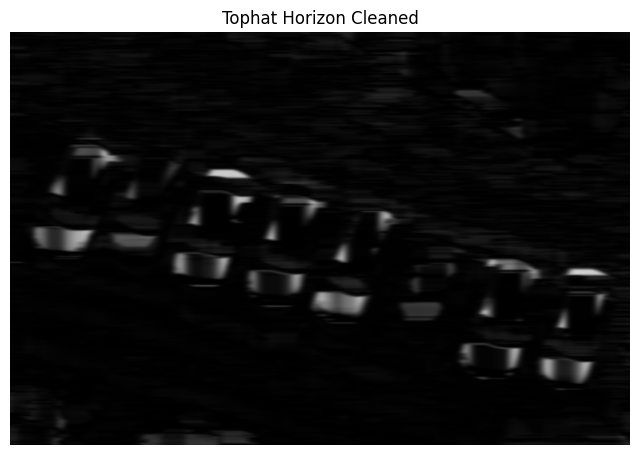

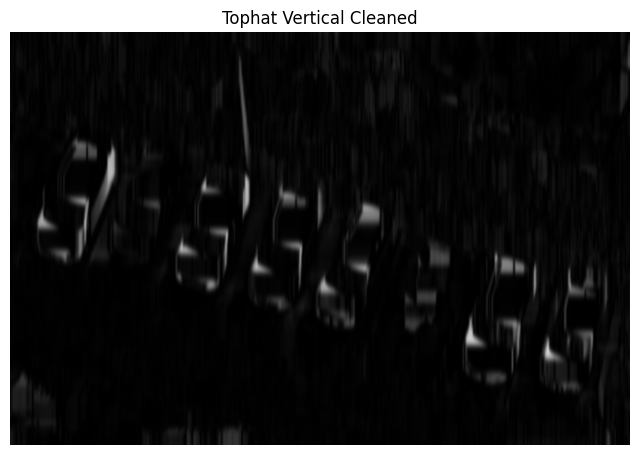

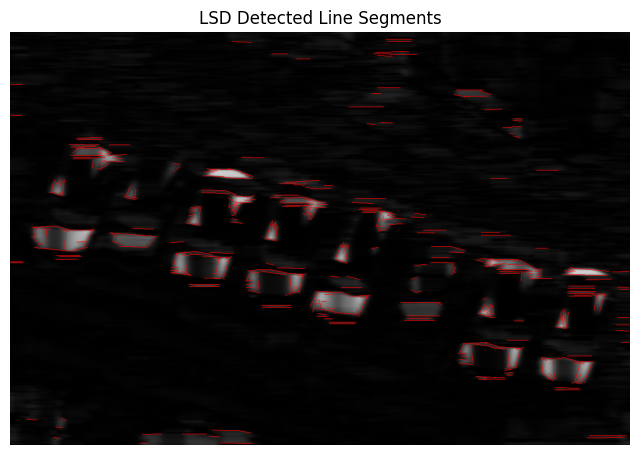

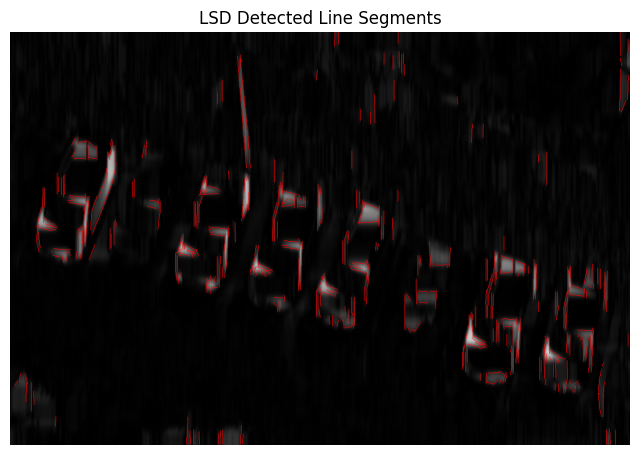

In [53]:
# --- EASY

#do_pipeline(images, "easy", "29.png")
#do_pipeline(images, "easy", "not_that_easy.jpg")
#do_pipeline(images, "easy", "easy.jpg")
#do_pipeline(images, "easy", "20.png")

# --- Medium 
#do_pipeline(images, "medium", "12.png")
#do_pipeline(images, "medium", "30.png")
#do_pipeline(images, "medium", "31.png")

# -- Hard
#do_pipeline(images, "hard", "frame600.jpg")
#do_pipeline(images, "hard", "frame1.jpg")
do_pipeline(images, "hard", "21.png")
